In [ ]:
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/animal-image-classification-5-species")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animal-image-classification-5-species' dataset.
Path to dataset files: /kaggle/input/animal-image-classification-5-species


In [ ]:
os.listdir(path)

['animals_dataset']

In [ ]:
animal = os.path.join(path,"animals_dataset")
animal

'/kaggle/input/animal-image-classification-5-species/animals_dataset'

In [ ]:
os.listdir(animal)

['validation', 'test', 'train']

In [ ]:
train_path = os.path.join(animal,"train")
train_path

'/kaggle/input/animal-image-classification-5-species/animals_dataset/train'

In [ ]:
test_path = os.path.join(animal,"test")
test_path

'/kaggle/input/animal-image-classification-5-species/animals_dataset/test'

In [44]:
valid_path = os.path.join(animal,"validation")
valid_path

'/kaggle/input/animal-image-classification-5-species/animals_dataset/validation'

In [11]:
cow = os.path.join(train_path,"cow")
cow

'/kaggle/input/animal-image-classification-5-species/animals_dataset/train/cow'

In [35]:
cow_img_path = os.path.join(cow,os.listdir(cow)[41])
cow_img_path

'/kaggle/input/animal-image-classification-5-species/animals_dataset/train/cow/images (28).jpeg'

In [32]:
import cv2
from PIL import Image

array([[[251, 247, 246],
        [251, 247, 246],
        [251, 247, 246],
        ...,
        [255, 255, 248],
        [255, 255, 248],
        [255, 255, 248]],

       [[251, 247, 246],
        [251, 247, 246],
        [251, 247, 246],
        ...,
        [255, 255, 250],
        [255, 255, 250],
        [255, 255, 250]],

       [[251, 247, 246],
        [251, 247, 246],
        [251, 247, 246],
        ...,
        [254, 255, 253],
        [254, 255, 253],
        [254, 255, 253]],

       ...,

       [[ 62, 125, 109],
        [ 37, 100,  84],
        [ 48, 107,  92],
        ...,
        [ 83, 145, 133],
        [120, 184, 172],
        [ 95, 157, 145]],

       [[ 43, 106,  90],
        [ 38, 101,  85],
        [ 28,  87,  72],
        ...,
        [ 64, 128, 116],
        [ 81, 147, 135],
        [ 78, 142, 130]],

       [[ 26,  89,  73],
        [  6,  69,  53],
        [ 36,  95,  80],
        ...,
        [ 85, 151, 139],
        [ 87, 153, 141],
        [ 87, 153, 141]]], dtype=uint8)
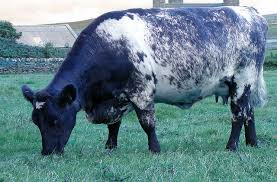

In [33]:
cv2.imread(cow_img_path)

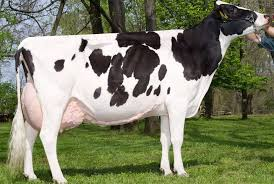

In [36]:
Image.open(cow_img_path)

array([[[ 29,  43,  39],
        [ 15,  29,  25],
        [ 23,  37,  33],
        ...,
        [128, 135, 138],
        [ 84,  91,  94],
        [ 54,  59,  60]],

       [[ 39,  50,  47],
        [ 36,  50,  44],
        [ 44,  55,  52],
        ...,
        [ 52,  59,  62],
        [ 49,  56,  59],
        [ 40,  45,  46]],

       [[ 26,  36,  30],
        [ 21,  34,  26],
        [ 30,  40,  34],
        ...,
        [ 70,  75,  78],
        [ 43,  48,  51],
        [ 21,  25,  26]],

       ...,

       [[ 89, 100, 114],
        [ 89, 102, 116],
        [ 86,  97, 111],
        ...,
        [121, 145, 173],
        [139, 163, 191],
        [158, 182, 210]],

       [[ 83,  92, 105],
        [ 82,  94, 106],
        [ 93, 102, 115],
        ...,
        [173, 197, 225],
        [137, 161, 189],
        [166, 190, 218]],

       [[ 82,  92, 102],
        [ 84,  94, 104],
        [ 93, 103, 113],
        ...,
        [119, 143, 171],
        [ 86, 110, 138],
        [120, 144, 172]]], dtype=uint8)
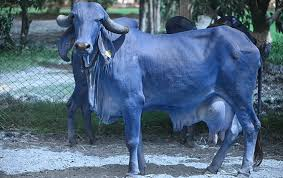

In [24]:
cv2.imread("/kaggle/input/animal-image-classification-5-species/animals_dataset/train/cow/images (11).jpeg")

In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [46]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(180,180),
    batch_size=32,
    shuffle=True,
    subset="training",
    validation_split=0.2,
    seed=123,
)

Found 464 files belonging to 5 classes.
Using 372 files for training.


In [47]:
test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(180,180),
    batch_size=32,
    shuffle=True,
    subset="validation",
    validation_split=0.2,
    seed=123,
)

Found 82 files belonging to 5 classes.
Using 16 files for validation.


In [48]:
valid_data = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=(180,180),
    batch_size=32,
    shuffle=True,
    subset="validation",
    validation_split=0.2,
    seed=123,
)

Found 83 files belonging to 5 classes.
Using 16 files for validation.


In [71]:
model = keras.Sequential([

    layers.Rescaling(1./255),

    layers.Conv2D(32,3,activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,3,activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,3,activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),          # ye line add karein
    layers.Dense(5,activation="softmax")
])

In [72]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [76]:
model.fit(train_data,epochs=25,validation_data=valid_data)

Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8253 - loss: 0.5152 - val_accuracy: 0.2500 - val_loss: 1.9586
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8844 - loss: 0.3579 - val_accuracy: 0.4375 - val_loss: 3.2817
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9140 - loss: 0.2706 - val_accuracy: 0.4375 - val_loss: 3.1038
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9220 - loss: 0.2158 - val_accuracy: 0.4375 - val_loss: 3.0499
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9220 - loss: 0.2448 - val_accuracy: 0.5000 - val_loss: 2.6623
Epoch 6/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9624 - loss: 0.1670 - val_accuracy: 0.3125 - val_loss: 4.5730
Epoch 7/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9462 - loss: 0.1529 - val_accuracy: 0.3125 - val_loss: 3.4952
Epoch 8/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9677 - loss: 0.1132 - val_accuracy: 0.3750 - v

In [77]:
model.evaluate(test_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5625 - loss: 4.1952


[4.195204257965088, 0.5625]

In [79]:
import gradio as gr
import numpy as np
from PIL import Image


class_names = train_data.class_names

def predict_image(img):
    img = img.resize((180,180))
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)


    predictions = model.predict(img_array)
    scores = tf.nn.softmax(predictions[0]) if predictions.shape[-1] > 1 else predictions[0]


    scores = predictions[0]


    result = {class_names[i]: float(scores[i]) for i in range(len(class_names))}
    return result


demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=5),
    title="Animal Classifier gardio",
    description="Koi bhi animal ki image upload karein — model uski species predict karega."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fe74b16737d6eb77fa.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


AttributeError: 'str' object has no attribute 'keras'